<a href="https://colab.research.google.com/github/roshnimishraa/Roshni-ML-with-Gen-AI/blob/main/Roshni_Mishra_02002212025_Week_2_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# load dataset
import pandas as pd

raw = pd.read_csv("/content/hospital.csv", header=None)

df = raw[0].str.split(",", expand=True)
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884.924
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.88,0,no,northwest,3866.8552


In [ ]:
print(df.shape)
print(df.info())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       1338 non-null   object
 1   gender    1338 non-null   object
 2   bmi       1338 non-null   object
 3   children  1338 non-null   object
 4   smoker    1338 non-null   object
 5   region    1338 non-null   object
 6   charges   1338 non-null   object
dtypes: object(7)
memory usage: 73.3+ KB
None


In [ ]:
# checking missing values
df.isnull().sum()

,0
0,
age,0
gender,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# convert numerical columns
num_cols = ["age","bmi","children","charges"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col])

In [ ]:
# check duplicates
print(df.duplicated().sum())

1


In [ ]:
df[df.duplicated()]

,age,gender,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
# Encode Categorical Variables
df = pd.get_dummies(
    df,
    columns=["gender","smoker","region"],
    drop_first=True
)

df.head()

,age,bmi,children,charges,gender_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


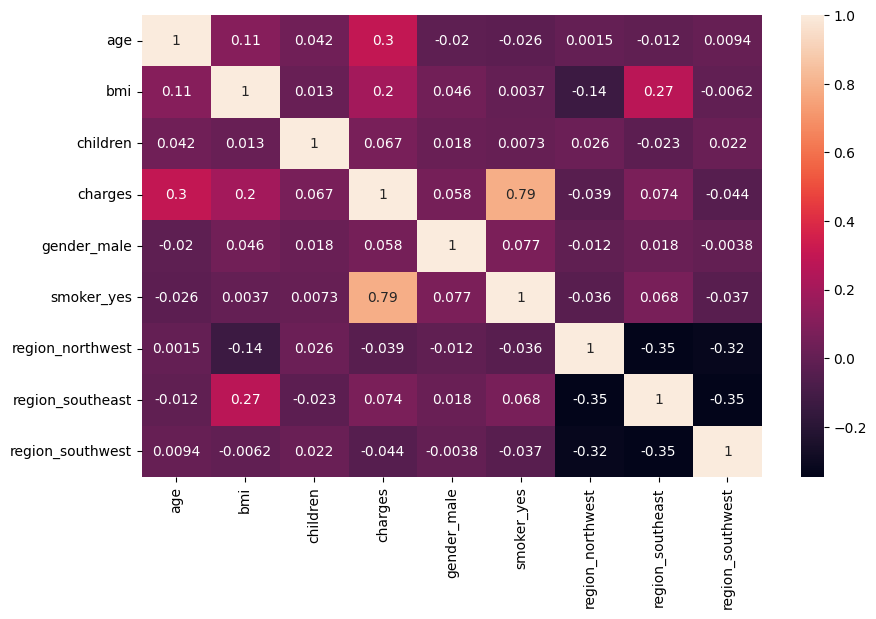

In [ ]:
# Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

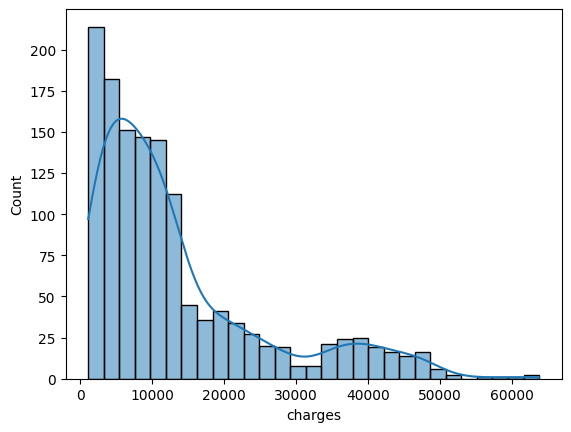

In [ ]:
# Distribution of Charges
sns.histplot(df["charges"], kde=True)
plt.show()

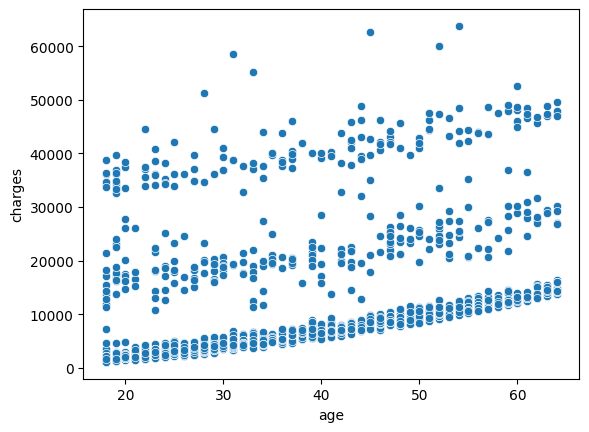

In [ ]:
# Age vs Charges
sns.scatterplot(x="age", y="charges", data=df)
plt.show()

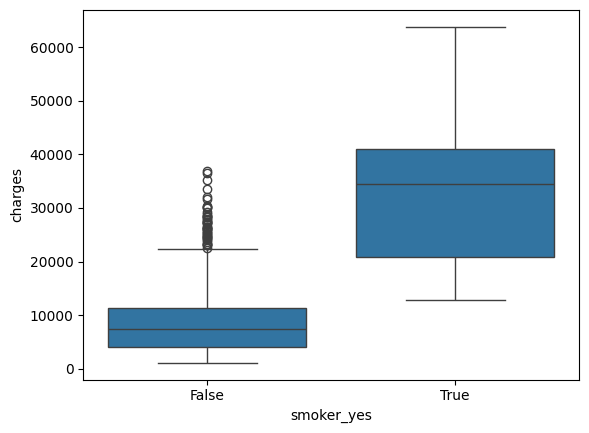

In [ ]:
# Smoker vs Charges
sns.boxplot(x="smoker_yes", y="charges", data=df)
plt.show()

In [ ]:
# train-test split
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# linear regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
# Evaluation
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, pred_lr))

R2 Score: 0.8069287081198011


In [ ]:
# Decision Tree
median_charge = y.median()

y_class = (y > median_charge).astype(int)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42
)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [ ]:
# accuracy
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, pred_dt))

0.8805970149253731


In [ ]:
# knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

print(accuracy_score(y_test, pred_knn))

0.8992537313432836


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_knn)

print(cm)

[[119  13]
 [ 14 122]]


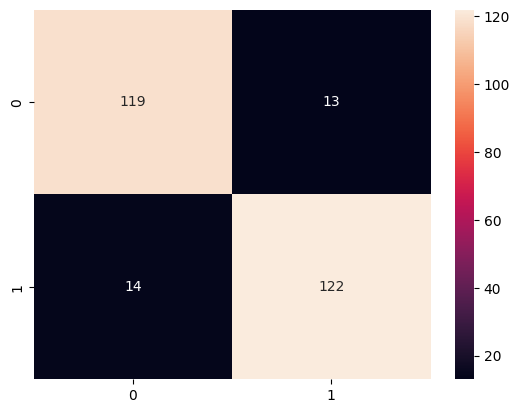

In [ ]:
# visualize
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

# Week 2 Assignment 2

## Q1.
A bank wants to predict whether a loan application will be approved or rejected.

### (i) Is this a classification or regression problem?

**Ans.** This is a Classification Problem because the output belongs to predefined categories such as Approved or Rejected.

### (ii) Which algorithm among Decision Tree, KNN, and Linear Regression would be most suitable?

**Ans.** Among Decision Tree, KNN, and Linear Regression, Decision Tree is the most suitable algorithm because it works well for classification tasks and provides easy-to-understand decision rules.

---

## Q2.
Explain the difference between a feature and a label using a real-world example.

**Ans.** In the Hospital Insurance Dataset, age, gender, BMI, number of children, smoker status, and region are features, while insurance charges are the label. A feature is an input variable used by the model to make predictions, whereas a label is the output variable that the model predicts. For example, the model uses age, BMI, smoker status, and region to predict insurance charges.

---

## Q3.
A Decision Tree predicts that a customer will purchase a product. Explain how the model reaches this prediction.

**Ans.** A Decision Tree reaches a prediction by asking a sequence of questions based on feature values. Starting from the root node, it checks conditions one by one and follows the corresponding branches. This process continues until a leaf node is reached, which contains the final prediction. Thus, the prediction is obtained through a series of decision rules.

---

## Q4.
Why is KNN considered a supervised learning algorithm? Can KNN perform classification if labels are not available?

**Ans.** KNN is considered a supervised learning algorithm because it learns from labeled training data. For a new data point, it finds the nearest neighbors and uses their labels to make a prediction. KNN cannot perform classification if labels are not available because it relies on the labels of neighboring data points to determine the output class.

---

## Q5.
Suppose a KNN model uses K = 5 and the nearest neighbors are:

Yes, Yes, No, Yes, No

What will be the prediction and why?

**Ans.** The prediction will be **Yes** because KNN uses majority voting. Among the five nearest neighbors, three belong to the class "Yes" and two belong to the class "No". Since "Yes" has the majority vote, the model predicts "Yes".

---

## Q6.
Explain the equation of Linear Regression:

y = mx + b

What do x, y, m, and b represent?

**Ans.** In the equation y = mx + b, x represents the independent variable or input feature, y represents the dependent variable or predicted output, m represents the slope of the line, and b represents the intercept. In the Hospital Insurance Dataset, age can be considered as x and insurance charges as y. Linear Regression finds the best-fit line that describes the relationship between the input variable and the target variable.

---

## Q7.
What is correlation?

What does each of the following values indicate?

+1

0

-1

**Ans.** Correlation measures the strength and direction of the relationship between two variables.

A correlation value of **+1** indicates a perfect positive correlation, meaning both variables increase together.

A correlation value of **0** indicates no correlation, meaning there is no relationship between the variables.

A correlation value of **-1** indicates a perfect negative correlation, meaning one variable increases while the other decreases.

In the Hospital Insurance Dataset, age and charges show a positive correlation, while smoker status has a strong positive correlation with insurance charges.

---

## Q8.
A disease detection model produced the following result:

Actual Condition: Disease Present

Prediction: Healthy

### (i) What type of prediction is this?

**Ans.** This is a False Negative (FN) prediction.

### (ii) Why can this be dangerous?

**Ans.** This prediction is dangerous because the patient actually has the disease, but the model predicts that the patient is healthy. As a result, treatment may be delayed, allowing the disease to progress and potentially causing serious health complications.

---

## Q9.
What is the purpose of a Confusion Matrix?

How is it different from a Correlation Matrix?

**Ans.** A Confusion Matrix is used to evaluate the performance of a classification model. It summarizes the number of True Positives, True Negatives, False Positives, and False Negatives made by the model.

A Correlation Matrix is used to measure the relationships between variables in a dataset. It helps identify how strongly variables are related to one another.

The main difference is that a Confusion Matrix evaluates model performance, whereas a Correlation Matrix analyzes relationships among features during exploratory data analysis.

---

## Q10.
Compare the following algorithms in one or two lines each:

### Decision Tree

**Ans.** Decision Tree uses a tree-like structure of rules and conditions to make predictions. It is easy to understand and interpret.

### KNN

**Ans.** KNN predicts the output based on the labels of the nearest neighboring data points and uses majority voting for classification.

### SVM

**Ans.** SVM finds the optimal hyperplane that best separates different classes in the dataset and maximizes the margin between them.

### Linear Regression

**Ans.** Linear Regression predicts continuous numerical values by fitting a straight line between input features and the target variable.

### Neural Network

**Ans.** Neural Networks consist of interconnected layers of neurons that learn complex patterns and relationships from data, making them useful for solving advanced machine learning problems.